In [1]:
import os
os.environ["R_HOME"] = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R"

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"
os.environ["PATH"] = f"{qiime_env}/bin:/usr/local/bin:/usr/bin:/bin"
os.environ["CONDA_PREFIX"] = qiime_env


In [2]:
from ancombc2_heatmaps import ANCOMBC2HeatmapPlotter, HeatmapConfig

print("Import funktioniert 👍")

Import funktioniert 👍


In [3]:
from ancombc2_heatmaps import (
    ANCOMBC2HeatmapPlotter,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec
)

In [14]:
from ancombc2_heatmaps import (
    ANCOMBC2HeatmapPlotter,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec
)

# =========================================================
# TIMEPOINTS
# =========================================================
TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_MAP = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",

    # falls sie schon korrekt sind
    "baseline1": "baseline1",
    "baseline2": "baseline2",
    "baseline3": "baseline3",
    "day1": "day1",
    "day3": "day3",
    "day7": "day7",
    "day14": "day14",
}

# =========================================================
# CONFIG
# =========================================================
config = HeatmapConfig(
    metadata=MetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        comparison_col="sex",
        timepoints=TIMEPOINTS,
        timepoint_map=TIMEPOINT_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male", "female"],
        },
    ),
    comparison=ComparisonConfig(
        variable_name="sex",
        positive_class="male",
        negative_class="female"
    ),
    paths=PathConfig(
        base_table_dir="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex",
        base_ancom_dir="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex",
        metadata_path="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt",
        output_dir="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/test_package_plots",
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    cell_text_mode="relative_abundance",
    split_after_timepoint="baseline3",
    min_sig_cells_per_taxon=1,
)

In [15]:
subset = SubsetSpec(
    label="all_genus_ANCOM",   # MUSS zu deinen Dateinamen passen!
    title="all samples",
    filters={}
)

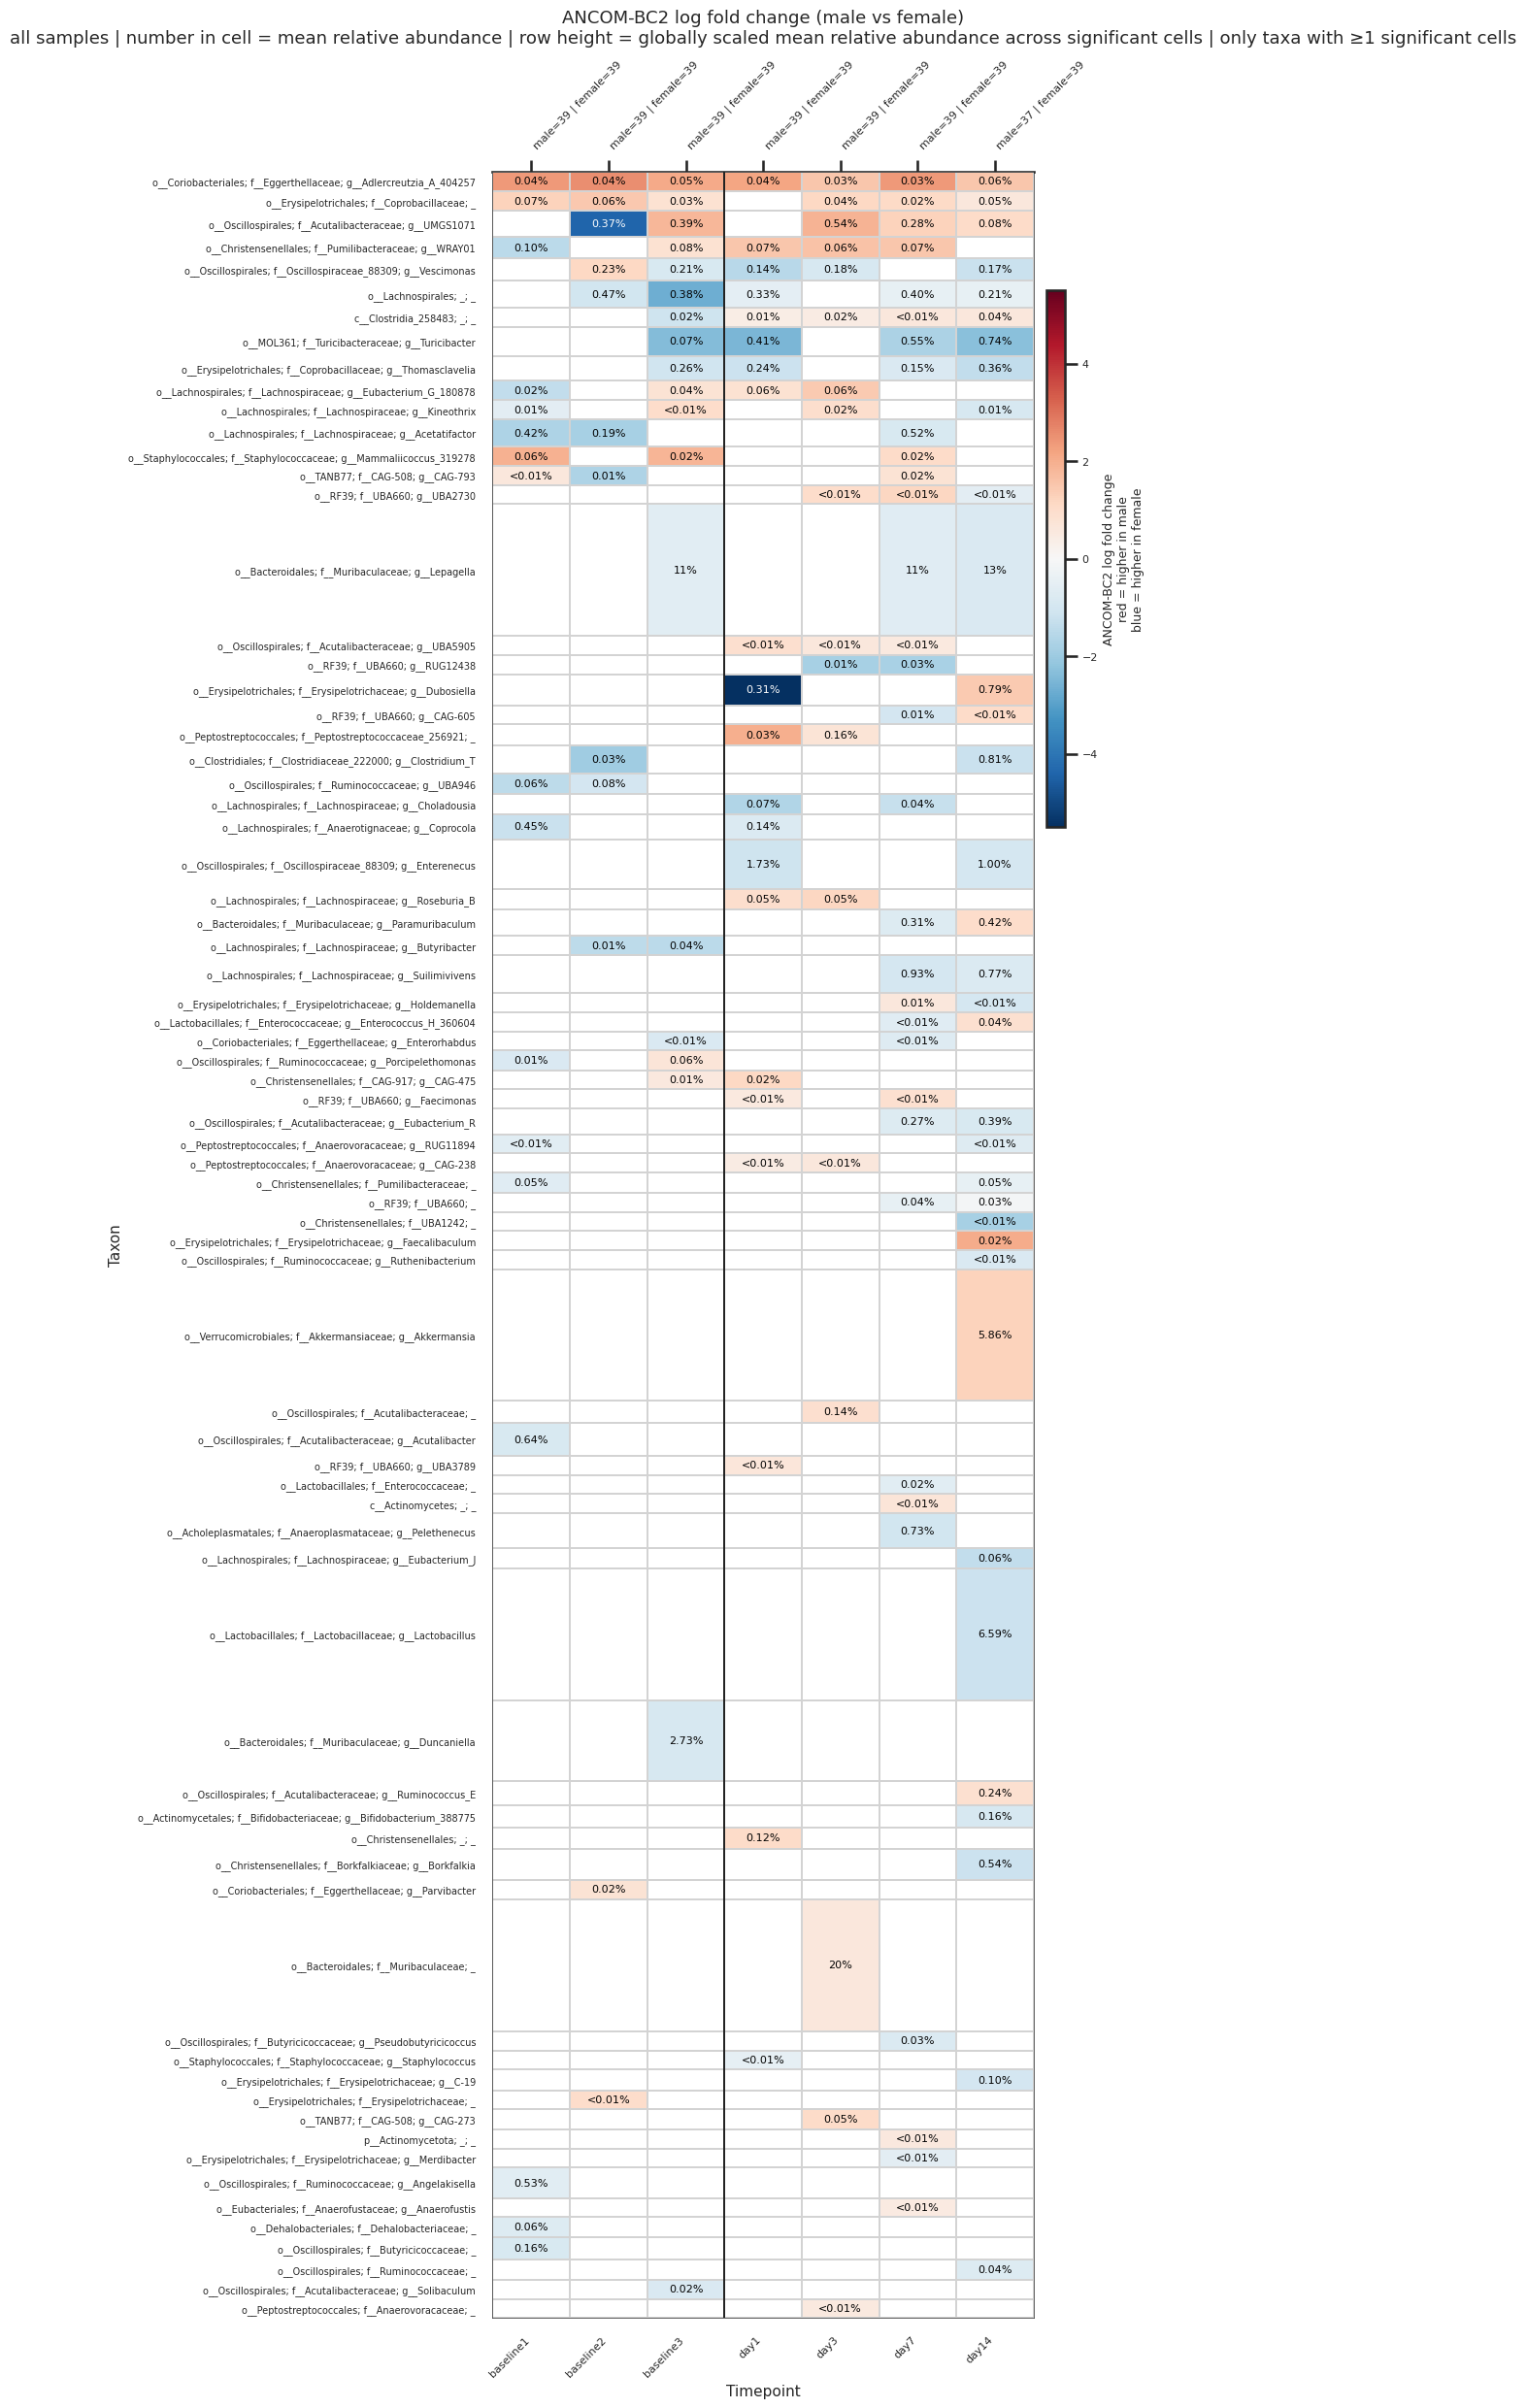

In [16]:
plotter = ANCOMBC2HeatmapPlotter(config)

meta = plotter.load_metadata()

plotter.plot_subset(
    meta_df=meta,
    subset=subset,
    save_png=False,
    save_pdf=False,
    show=True
)

In [17]:
subset = SubsetSpec(
    label="WT_sham_genus_ANCOM",
    title="WT | sham",
    filters={
        "mice_model": "WT",
        "description_of_treatment": "sham"
    }
)

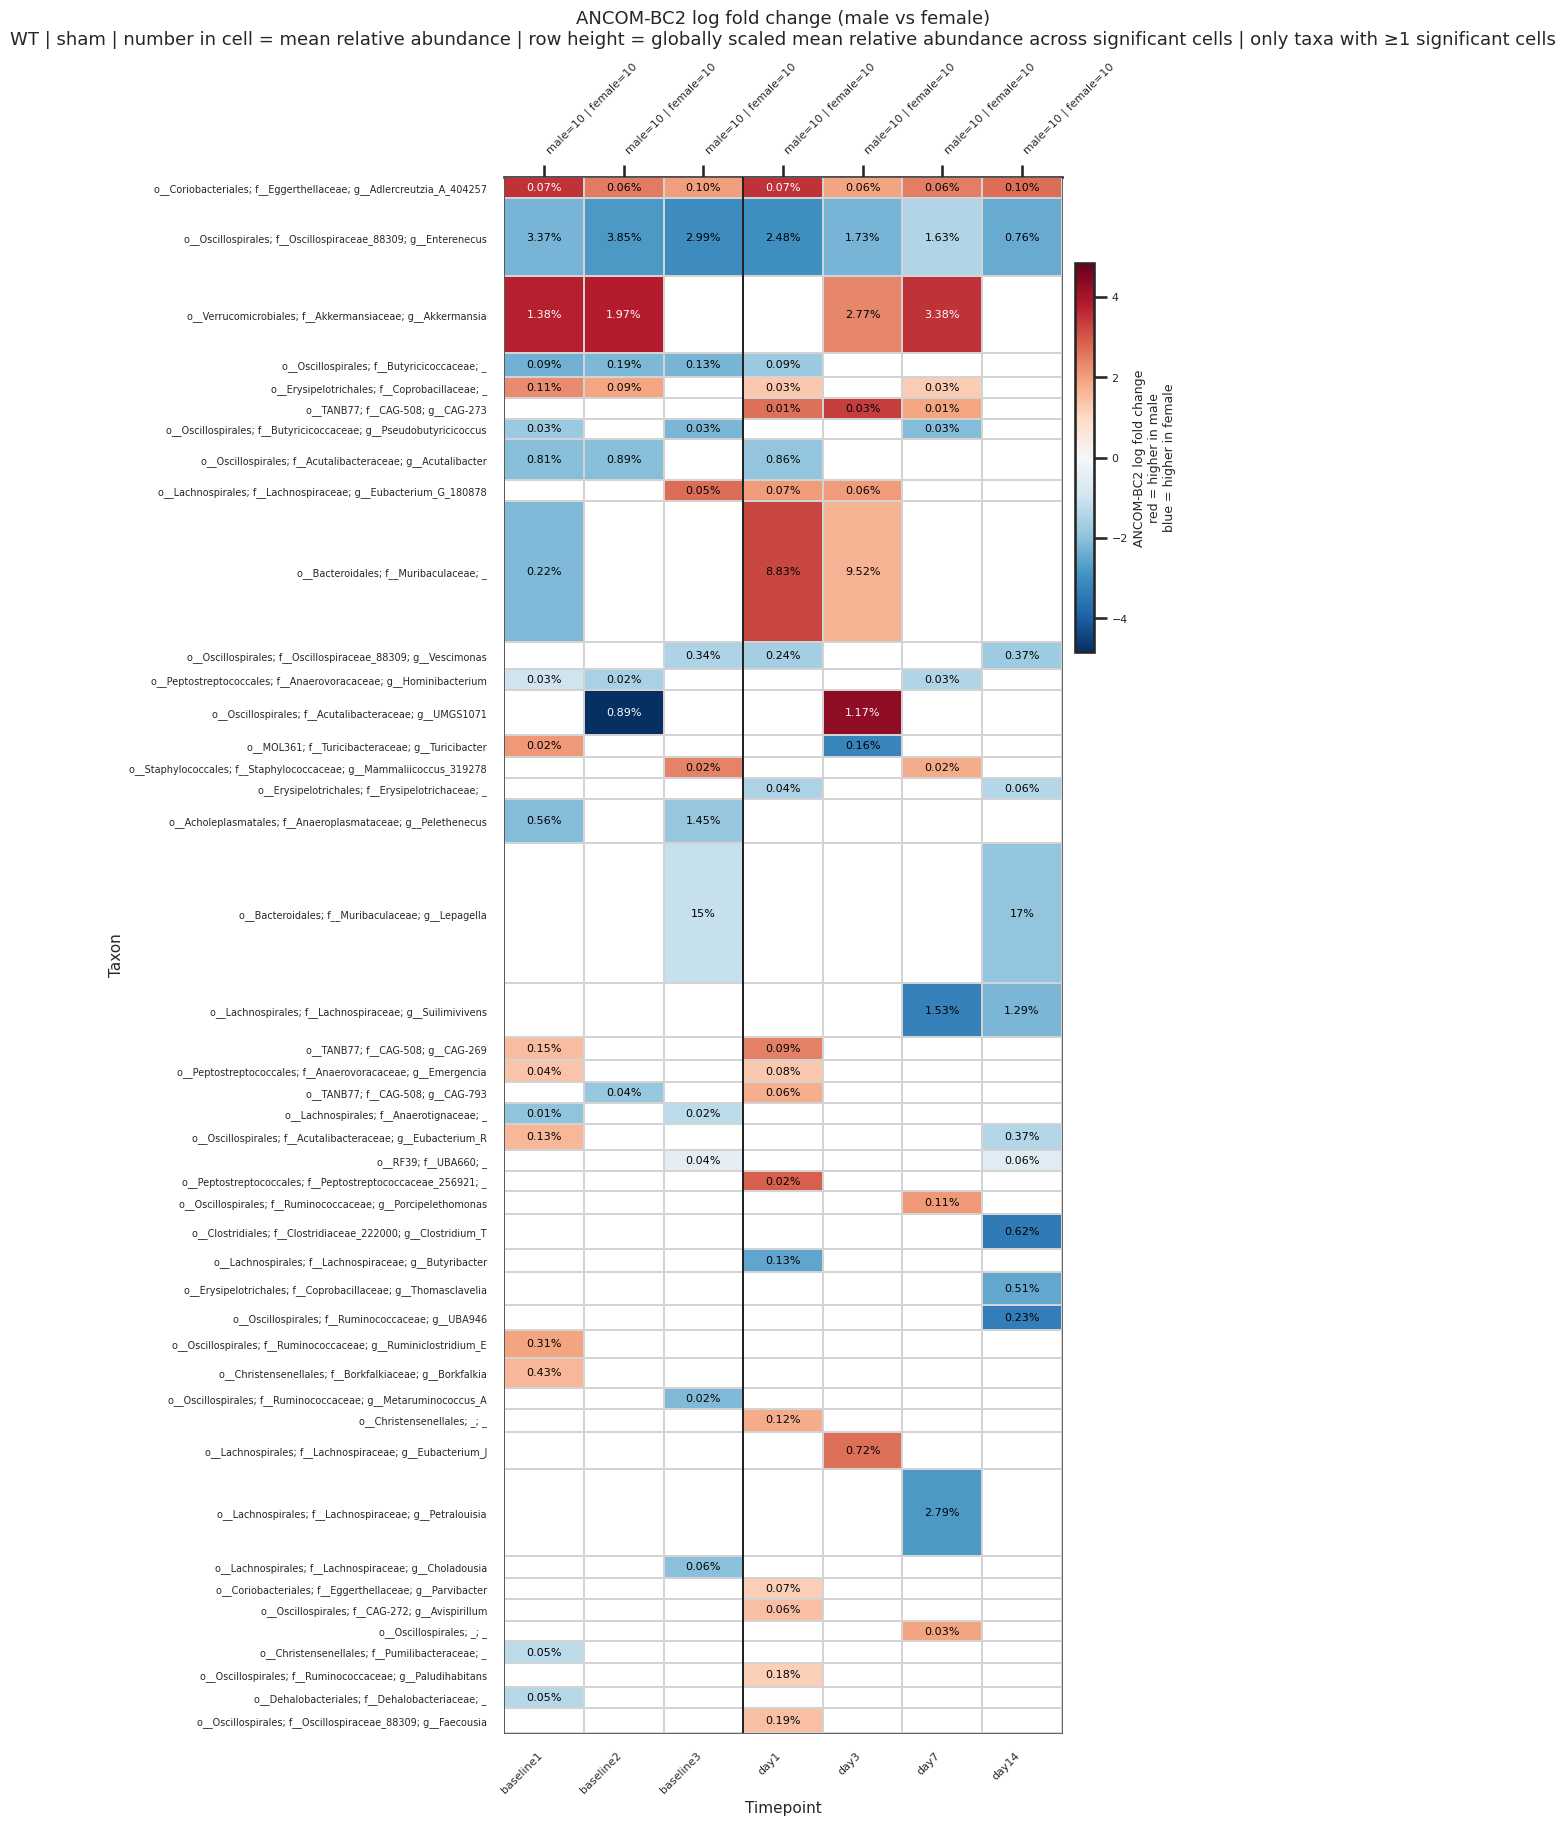

In [18]:
plotter = ANCOMBC2HeatmapPlotter(config)
meta = plotter.load_metadata()

plotter.plot_subset(
    meta_df=meta,
    subset=subset,
    save_png=False,
    save_pdf=False,
    show=True
)

In [19]:
subsets = [
    SubsetSpec(
        label="WT_sham_genus_ANCOM",
        title="WT | sham",
        filters={"mice_model": "WT", "description_of_treatment": "sham"}
    ),
    SubsetSpec(
        label="WT_irradiated_genus_ANCOM",
        title="WT | irradiated",
        filters={"mice_model": "WT", "description_of_treatment": "irradiated"}
    ),
    SubsetSpec(
        label="Apc_sham_genus_ANCOM",
        title="Apc | sham",
        filters={"mice_model": "Apc", "description_of_treatment": "sham"}
    ),
    SubsetSpec(
        label="Apc_irradiated_genus_ANCOM",
        title="Apc | irradiated",
        filters={"mice_model": "Apc", "description_of_treatment": "irradiated"}
    ),
]

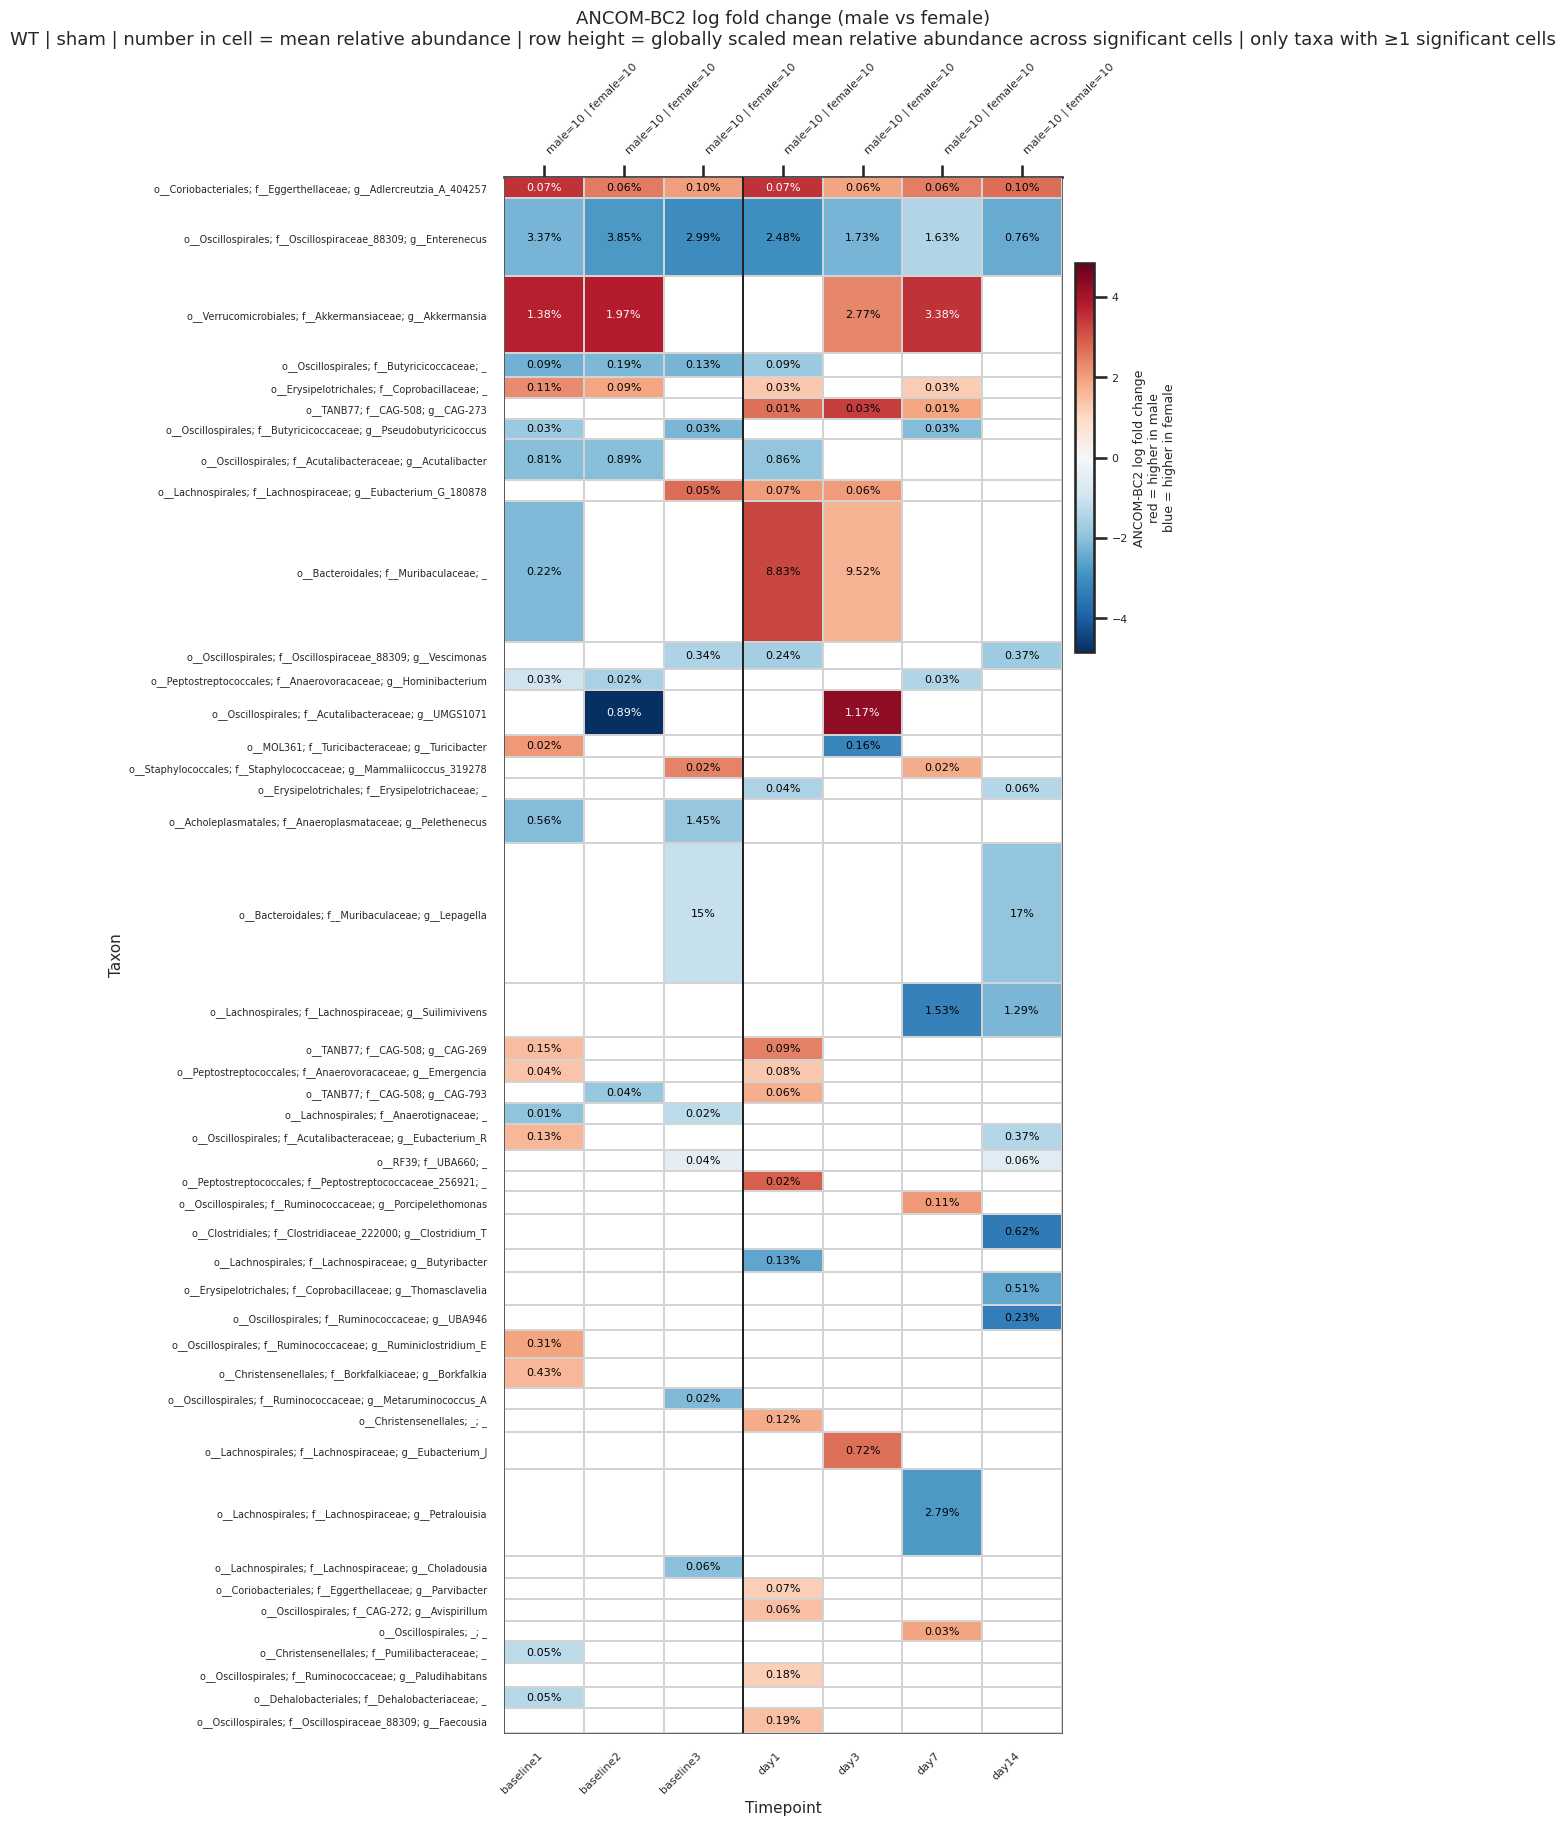

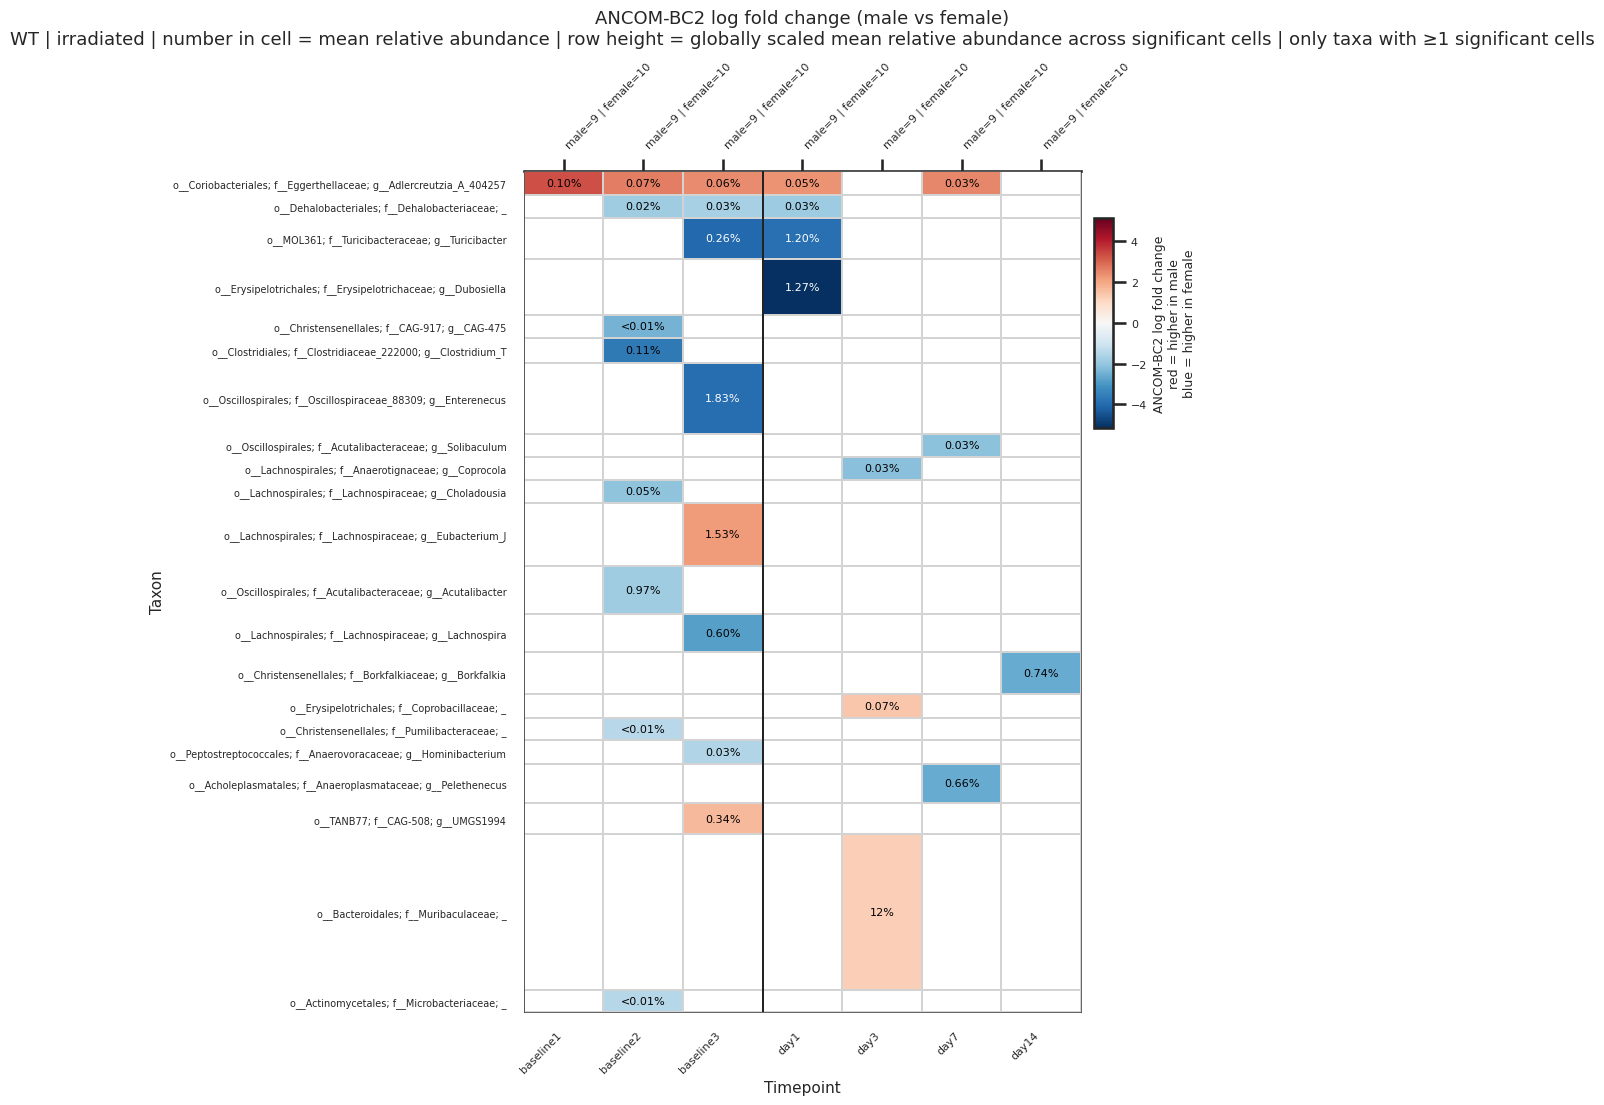

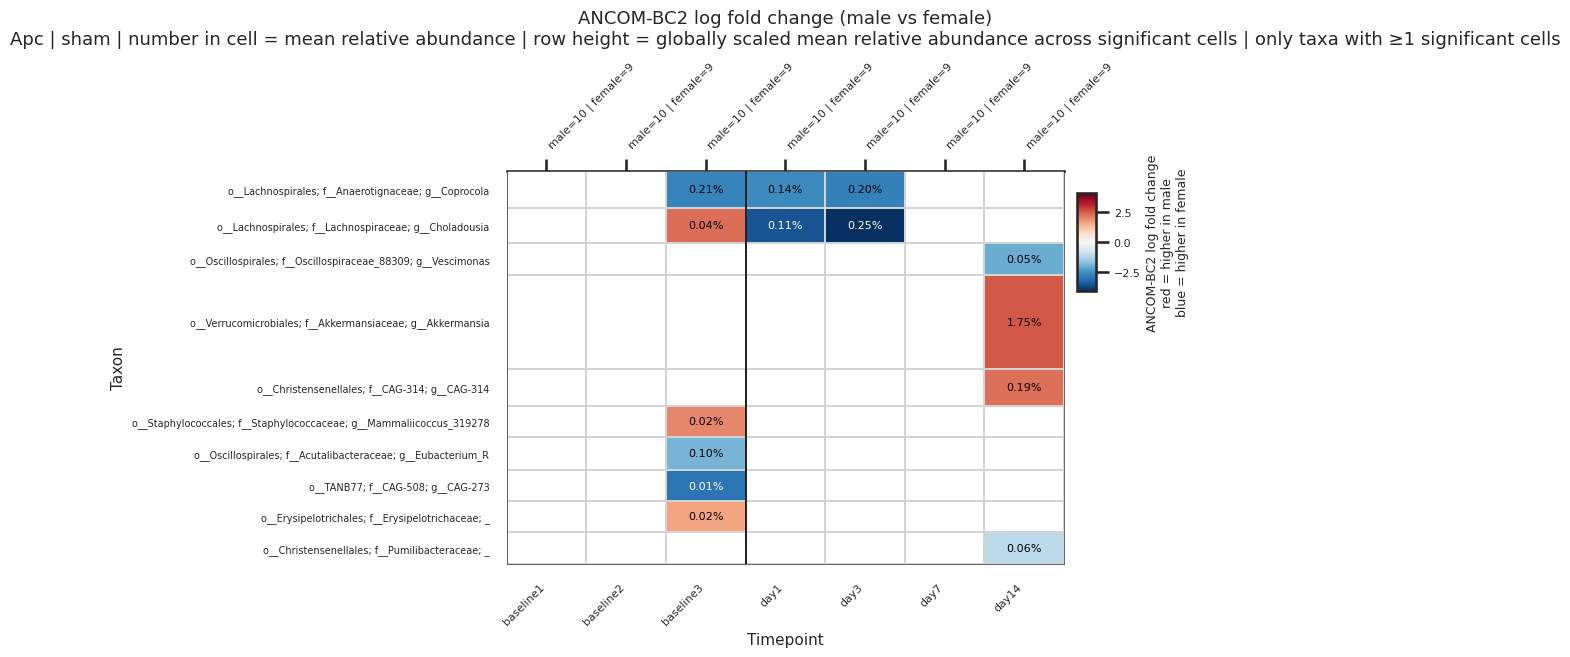

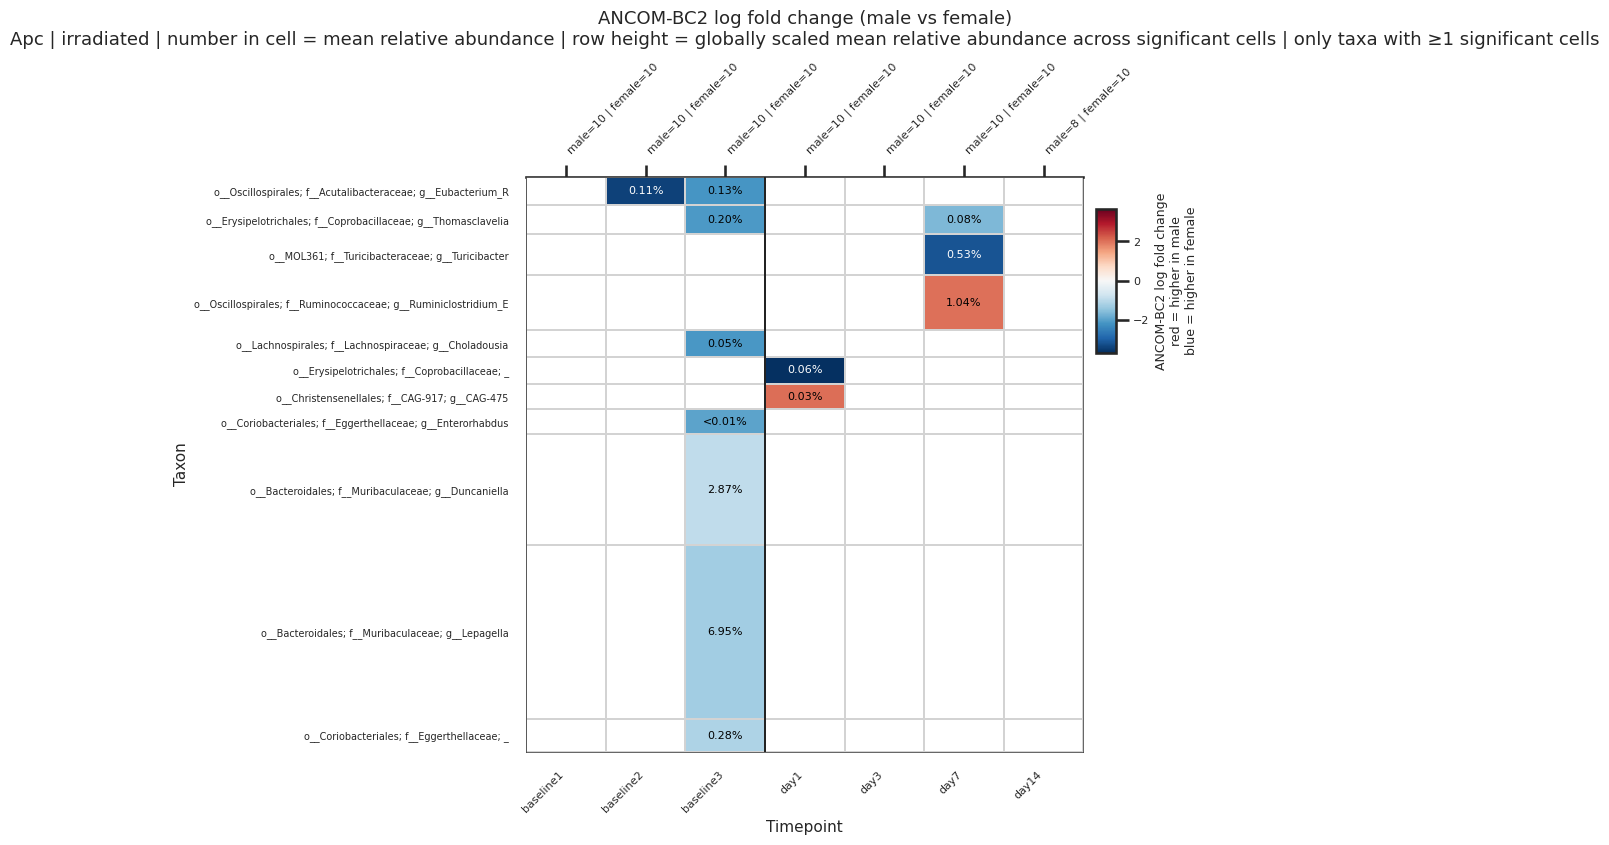

In [20]:
plotter.plot_all_subsets(subsets, save_png=False, save_pdf=False, show=True)